In [1]:
import sys
import os

# Get the absolute path to the project directory
project_dir = os.path.abspath("..")

# Append the project directory to sys.path
if project_dir not in sys.path:
    sys.path.append(project_dir)
    
from src.predictionModule.TreeTimeML import TreeTimeML
from src.predictionModule.LoadupSamples import LoadupSamples
from src.hyperparameterTuning.HelperMetrics import HelperMetrics
from src.mathTools.RegimeChange import RegimeChange

from src.predictionModule.MachineModels import MachineModels

import pandas as pd
import numpy as np
import polars as pl
import datetime
import seaborn as sns
import lightgbm as lgb
import random
import matplotlib.pyplot as plt
import seaborn as sns
import logging
logging.basicConfig(
    level=logging.DEBUG,
    format='%(message)s'
)
logger = logging.getLogger(__name__)

In [2]:
params = {
    "idxAfterPrediction": 8,
    'timesteps': 65,
    'LoadupSamples_time_scaling_stretch': False,
    'LoadupSamples_tree_scaling_standard': False,
    "LoadupSamples_time_inc_factor": 1,
}

In [3]:
timegroup = "group_regOHLCV_to2014"
stock_group = "group_dez_lowspread"
stock_group_short = '_'.join(stock_group.split('_')[1:])

global_start_date = datetime.date(2018, 1, 1)
final_eval_date = datetime.date(2025, 10, 15)
n_test_days=7
test_dates = [final_eval_date - datetime.timedelta(days=i) for i in range(n_test_days)][::-1]

ls = LoadupSamples(
    train_start_date=global_start_date,
    test_dates=test_dates,
    treegroup=stock_group,
    timegroup=timegroup,
    params=params,
)

In [4]:
ls.load_samples(main_path = "../src/featureAlchemy/bin/")

Test date 2025-10-11 not found in the database. Omitting.
Test date 2025-10-12 not found in the database. Omitting.


In [5]:
Xtree = ls.train_Xtree
ytree = ls.train_ytree

treenames = ls.featureTreeNames
timenames = ls.featureTimeNames

meta_tr = ls.meta_pl_train
meta_te = ls.meta_pl_test

In [6]:
np.mean(np.log(ytree[:, 4]))

np.float64(0.0012190920901457567)

In [7]:
HelperMetrics.evaluate_mask_nullonempty(np.ones(Xtree.shape[0], dtype=bool), meta_tr.get_column("date"), ytree[:, 4])

1.0020217548887635

### Get mask treenames

In [56]:
import re
tn = np.asarray(treenames, str)
mask_treenames = np.array(
    [(m:=re.search(r'_lag_m(\d+)', s)) is None or int(m.group(1)) <= 1
                           for s in tn]
)
    
print(f"Using {np.sum(mask_treenames)} / {len(treenames)} tree features.")

Using 568 / 1666 tree features.


In [57]:
def colinearity_mask_with_target(
    X: np.ndarray,
    y: np.ndarray,
    m: int,
    thr: float = 0.9,
    row_ratio: float = 1.0,
    random_state: int | None = None,
) -> np.ndarray:
    """
    Select up to m features that are:
    - highly correlated with the target y, but
    - not too correlated (>|thr|) with already selected features.

    Features are processed in descending order of |corr(feature, y)|.
    """
    n, p = X.shape
    if y.shape[0] != n:
        raise ValueError("X and y must have the same number of rows")

    # Optional row subsampling (same idea as your original function)
    if row_ratio < 1.0:
        rng = np.random.default_rng(random_state)
        k = max(2, int(n * row_ratio))
        idx = rng.choice(n, k, replace=False)
        Xc = X[idx]
        yc = y[idx]
    else:
        Xc = X
        yc = y

    # Feature-feature correlation matrix
    corr = np.corrcoef(Xc, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0)

    # Feature-target correlations
    xc = Xc - Xc.mean(axis=0, keepdims=True)
    yc0 = yc - yc.mean()
    num = (xc * yc0[:, None]).sum(axis=0)
    den = np.sqrt((xc**2).sum(axis=0) * (yc0**2).sum())
    with np.errstate(divide="ignore", invalid="ignore"):
        corr_y = num / den
    corr_y = np.nan_to_num(corr_y, nan=0.0)

    # Order features by descending |corr(feature, y)|
    order = np.argsort(-np.abs(corr_y))
    keep = np.zeros(p, dtype=bool)

    # Greedy selection: high |corr with y|, low |corr with already kept|
    for j in order:
        if keep.sum() >= m:
            break
        if not keep.any() or np.all(np.abs(corr[j, keep]) <= thr):
            keep[j] = True

    return keep

mask_colin = colinearity_mask_with_target(Xtree[:, mask_treenames], ytree[:, -1], m=20, thr=0.15, row_ratio = 0.5)
mask_treenames_colin = mask_treenames.copy()
mask_treenames_colin[mask_treenames_colin] = mask_colin
print(f"Keeping {np.sum(mask_treenames_colin)}/{len(mask_treenames_colin)} features after colinearity filter.")

for fi in np.where(mask_treenames_colin)[0]:
    print(f"- {treenames[fi]}")

Keeping 20/1666 features after colinearity filter.
- Category_technology
- FinData_quar_reportedEPS_nivRevLag_qm1
- FinData_quar_reportedEPS_lagquot_qm1
- FinData_quar_reportedEPS_lagquot_qm2
- FinData_quar_grossProfit_lagquot_qm3
- FinData_quar_ebitda_lagquot_qm4
- FinData_quar_reportedEPS_lagquot_qm5
- FinData_quar_reportedEPS_nivRevLag_qm6
- FinData_quar_grossProfit_lagquot_qm8
- FinData_quar_grossProfit_nivRevLag_qm10
- FinData_quar_estimatedEPS_nivRevLag_qm11
- FinData_ann_totalAssets_lagquot_am1
- FinData_metrics_log_forward_pe_ratio_lagquot_m20
- MathFeature_Drawdown_MH4
- Seasonal_quarter
- Seasonal_is_month_end
- Seasonal_days_since_last_holiday
- FeatureTA_volatility_dcl
- FeatureTA_momentum_pvo_hist_lag_m1
- FeatureGroup_WeightedIndexPct_lag_m1


## Main

In [58]:
mm_params = {
    "LGB_num_boost_round": 50,
    "LGB_lambda_l1": 0.00001,
    "LGB_lambda_l2": 0.00001,
    "LGB_feature_fraction":1.0,
    "LGB_num_leaves": 500,
    "LGB_max_depth": 6,
    "LGB_learning_rate": 0.0001,
    "LGB_min_data_in_leaf": 1,
    "LGB_min_gain_to_split": 0.0001,
    "LGB_path_smooth": 0.2,
    "LGB_min_sum_hessian_in_leaf": 0.25,
    "LGB_max_bin": 240,
    "LGB_early_stopping_rounds": 100,
}

In [62]:
import numpy as np

# ---- helpers ----
nS = Xtree.shape[0]
mm = MachineModels(mm_params)
device = 'cuda'

def lgbm_mask(X, y, Xte, q, val_split=0.05):
    nS = X.shape[0]
    nS_tr = int(nS * (1 - val_split))
    X_tr, y_tr = X[:nS_tr], y[:nS_tr]
    X_val, y_val = X[nS_tr:], y[nS_tr:]
    model, _ = mm.run_LGB(X_tr, y_tr, X_val, y_val)
    yhat_tr = model.predict(X)
    yhat_te = model.predict(Xte)
    qhat_tr = np.quantile(yhat_tr, q)
    mask_top_tr = yhat_tr >= qhat_tr
    mask_top_te = yhat_te >= qhat_tr
    return mask_top_tr, mask_top_te

q = 0.99
nRange = 3
for frac in np.linspace(0.3, 0.85, 8):  # 5 different train sizes
    nS_tr = int(nS * frac)
    nS_tr_ff = int(nS * (frac + 0.01))
    print(f"\n=== Train fraction {frac:.2f} (date={meta_tr['date'][nS_tr]}) ===")

    arr_tr = Xtree[:nS_tr][:, mask_treenames_colin]
    arr_te = Xtree[nS_tr:nS_tr_ff][:, mask_treenames_colin]
    dates_tr = meta_tr['date'][:nS_tr]
    dates_te = meta_tr['date'][nS_tr:nS_tr_ff]
    y_tr = ytree[:nS_tr][:, 4]
    y_te = ytree[nS_tr:nS_tr_ff][:, 4]

    X_tr, X_te = arr_tr, arr_te
    mask_tr = np.zeros(X_tr.shape[0], dtype=bool)
    mask_te = np.zeros(X_te.shape[0], dtype=bool)

    for i in range(nRange):
        print(f"Iteration {i+1}/{nRange}")
        neg_mask_tr = ~mask_tr
        neg_mask_te = ~mask_te
        Xtr_it, ytr_it = X_tr[neg_mask_tr], y_tr[neg_mask_tr]
        Xte_it, yte_it = X_te[neg_mask_te], y_te[neg_mask_te]

        m_tr_it, m_te_it = lgbm_mask(Xtr_it, ytr_it, Xte_it, q)
        mask_tr[neg_mask_tr] |= m_tr_it
        mask_te[neg_mask_te] |= m_te_it

        print(f"  Current masked train target mean: {np.exp(np.mean(np.log(y_tr[mask_tr])))}")
        print(f"  Current masked test target mean: {np.exp(np.mean(np.log(y_te[mask_te])))}")
        print(f"  Ratio of selected train samples: {mask_tr.sum()}/{len(mask_tr)} = {mask_tr.sum()/len(mask_tr):.4f}")
        print(f"  Ratio of selected test samples: {mask_te.sum()}/{len(mask_te)} = {mask_te.sum()/len(mask_te):.4f}")


Iteration 0: train's rmse: 0.04663494360556683, valid's rmse: 0.09188279375877281



=== Train fraction 0.30 (date=2020-05-04) ===
Iteration 1/3


Iteration 0: train's rmse: 0.044224514279506216, valid's rmse: 0.09250090755192433
Iteration 0: train's rmse: 0.04338087756889523, valid's rmse: 0.09747687816146455


  Current masked train target mean: 1.047707883082811
  Current masked test target mean: 1.0407898676448326
  Ratio of selected train samples: 718/55189 = 0.0130
  Ratio of selected test samples: 158/1840 = 0.0859
Iteration 2/3
  Current masked train target mean: 1.0327475839563973
  Current masked test target mean: 1.0625189289894748
  Ratio of selected train samples: 1357/55189 = 0.0246
  Ratio of selected test samples: 281/1840 = 0.1527
Iteration 3/3


Iteration 0: train's rmse: 0.05067222767621324, valid's rmse: 0.05655235374658197


...

  Current masked train target mean: 1.0315676800915128
  Current masked test target mean: 1.0069792863702325
  Ratio of selected train samples: 5807/141916 = 0.0409
  Ratio of selected test samples: 4/1840 = 0.0022

=== Train fraction 0.85 (date=2024-08-13) ===
Iteration 1/3


Iteration 0: train's rmse: 0.04529024428066757, valid's rmse: 0.04356560045675702


  Current masked train target mean: 1.0484125636237218
  Current masked test target mean: 1.0236069443232416
  Ratio of selected train samples: 2284/156371 = 0.0146
  Ratio of selected test samples: 16/1839 = 0.0087
Iteration 2/3


Iteration 0: train's rmse: 0.044557426159371256, valid's rmse: 0.04287783504353499


  Current masked train target mean: 1.0343213216183589
  Current masked test target mean: 0.9845832398365554
  Ratio of selected train samples: 4705/156371 = 0.0301
  Ratio of selected test samples: 28/1839 = 0.0152
Iteration 3/3
  Current masked train target mean: 1.030895730609574
  Current masked test target mean: 0.9845832398365554
  Ratio of selected train samples: 6849/156371 = 0.0438
  Ratio of selected test samples: 28/1839 = 0.0152


In [13]:
## ---- pick time-spread, high-target subsets ----
#idx_tr_subset = select_time_spread_subset(
#    dates_tr, yhat_tr,n_bins=200, per_bin=5)
#idx_te_subset = select_time_spread_subset(
#    dates_te, yhat_te,n_bins=200, per_bin=5)
#
## resulting subsets:
#arr_tr_sub, y_tr_sub, dates_tr_sub  = arr_tr[idx_tr_subset], y_tr[idx_tr_subset], dates_tr[idx_tr_subset]
#arr_te_sub, y_te_sub, dates_te_sub  = arr_te[idx_te_subset], y_te[idx_te_subset], dates_te[idx_te_subset]

#mask_tr = yhat_tr >= np.quantile(yhat_tr, 0.50)

arr_tr_sub, y_tr_sub, dates_tr_sub  = arr_tr[mask_tr], y_tr[mask_tr], dates_tr.filter(mask_tr)
arr_te_sub, y_te_sub, dates_te_sub  = arr_te[mask_te], y_te[mask_te], dates_te.filter(mask_te)

print(f"Ratio of selected train samples: {len(arr_tr_sub)}/{len(arr_tr)} = {len(arr_tr_sub)/len(arr_tr):.4f}")
print(f"ytr mean full: {np.mean(y_tr):.4f}, ytr mean subset: {np.mean(np.log(y_tr_sub)):.4f}")

print(f"Ratio of selected test samples: {len(arr_te_sub)}/{len(arr_te)} = {len(arr_te_sub)/len(arr_te):.4f}")
print(f"yte mean full: {np.mean(y_te):.4f}, yte mean subset: {np.mean(np.log(y_te_sub)):.4f}")


Ratio of selected train samples: 11554/156371 = 0.0739
ytr mean full: 1.0024, ytr mean subset: 0.0267
Ratio of selected test samples: 1396/18396 = 0.0759
yte mean full: 1.0007, yte mean subset: 0.0043


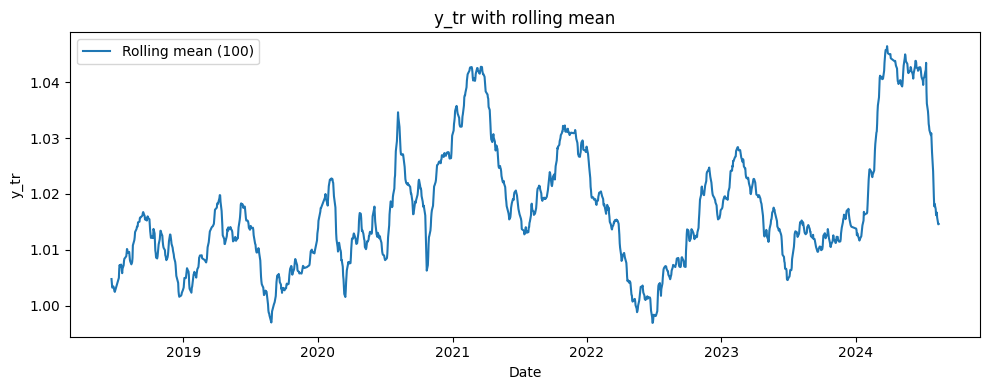

In [15]:
assert dates_tr_sub.is_sorted()
dates_tr_sorted = dates_tr_sub
y_tr_sorted = y_tr_sub

window = 100
comb_pl = pl.DataFrame({
    "date": dates_tr_sorted,
    "y_tr": y_tr_sorted
})
perdate_mean = comb_pl.group_by("date").agg(pl.col("y_tr").mean().alias("y_tr_mean")).sort("date")
perdate_mean_rolling = perdate_mean.select(
    pl.col("y_tr_mean").rolling_mean(window_size=window).alias("y_tr_mean_rolling")
)

plt.figure(figsize=(10, 4))
#sns.lineplot(x=dates_tr_sorted, y=y_tr_sorted, label="y_tr", alpha=0.5)
sns.lineplot(x=perdate_mean['date'], y=perdate_mean_rolling['y_tr_mean_rolling'], label=f"Rolling mean ({window})")
plt.xlabel("Date")
plt.ylabel("y_tr")
plt.title("y_tr with rolling mean")
plt.legend()
plt.tight_layout()
plt.show()

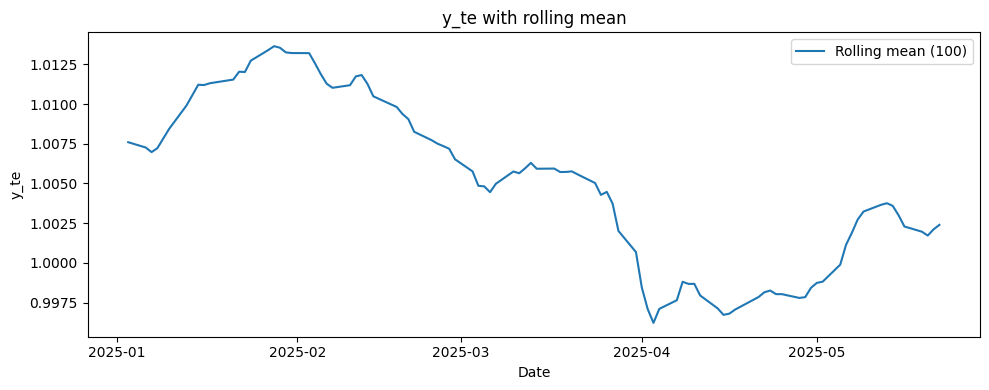

In [16]:
assert dates_te_sub.is_sorted()
dates_te_sorted = dates_te_sub
y_te_sorted = y_te_sub

window = 100
comb_pl = pl.DataFrame({
    "date": dates_te_sorted,
    "y_te": y_te_sorted
})
perdate_mean = comb_pl.group_by("date").agg(pl.col("y_te").mean().alias("y_te_mean")).sort("date")
perdate_mean_rolling = perdate_mean.select(
    pl.col("y_te_mean").rolling_mean(window_size=window).alias("y_te_mean_rolling")
)

plt.figure(figsize=(10, 4))
#sns.lineplot(x=dates_te_sorted, y=y_te_sorted, label="y_te", alpha=0.5)
sns.lineplot(x=perdate_mean['date'], y=perdate_mean_rolling['y_te_mean_rolling'], label=f"Rolling mean ({window})")
plt.xlabel("Date")
plt.ylabel("y_te")
plt.title("y_te with rolling mean")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
ytree_te_sub = ytree[nS_tr:nS_tr_ff][mask_te]
ytree_tr_sub = ytree[:nS_tr][mask_tr]
pivot_idx = 3


def gmean(x):
    return np.exp(np.mean(np.log(x)))
for threshold in np.linspace(0.90, 1.1, 10):
    mask_thr = ytree_tr_sub[:,pivot_idx] > threshold
    gmean_value = gmean(ytree_tr_sub[mask_thr, 4])
    print(f"  G-Mean of ytree_tr_sub > {threshold:.2f}: {gmean_value:.4f},    count: {np.sum(mask_thr)}")
print(" ")
for threshold in np.linspace(0.90, 1.1, 10):
    mask_thr = ytree_tr_sub[:,pivot_idx] < threshold
    gmean_value = gmean(ytree_tr_sub[mask_thr, 4])
    print(f"  G-Mean of ytree_tr_sub < {threshold:.2f}: {gmean_value:.4f},    count: {np.sum(mask_thr)}")
print("")
for threshold in np.linspace(0.90, 1.1, 10):
    mask_thr = ytree_te_sub[:,pivot_idx] > threshold
    gmean_value = gmean(ytree_te_sub[mask_thr, 4])
    print(f"  G-Mean of ytree_te_sub > {threshold:.2f}: {gmean_value:.4f},    count: {np.sum(mask_thr)}")
print(" ")
for threshold in np.linspace(0.90, 1.1, 10):
    mask_thr = ytree_te_sub[:,pivot_idx] < threshold
    gmean_value = gmean(ytree_te_sub[mask_thr, 4])
    print(f"  G-Mean of ytree_te_sub < {threshold:.2f}: {gmean_value:.4f},    count: {np.sum(mask_thr)}")

  G-Mean of ytree_tr_sub > 0.90: 1.0313,    count: 11270
  G-Mean of ytree_tr_sub > 0.92: 1.0339,    count: 11014
  G-Mean of ytree_tr_sub > 0.94: 1.0380,    count: 10545
  G-Mean of ytree_tr_sub > 0.97: 1.0444,    count: 9742
  G-Mean of ytree_tr_sub > 0.99: 1.0554,    count: 8323
  G-Mean of ytree_tr_sub > 1.01: 1.0709,    count: 6418
  G-Mean of ytree_tr_sub > 1.03: 1.0924,    count: 4364
  G-Mean of ytree_tr_sub > 1.06: 1.1165,    count: 2857
  G-Mean of ytree_tr_sub > 1.08: 1.1435,    count: 1869
  G-Mean of ytree_tr_sub > 1.10: 1.1675,    count: 1265
 
  G-Mean of ytree_tr_sub < 0.90: 0.8743,    count: 284
  G-Mean of ytree_tr_sub < 0.92: 0.8980,    count: 540
  G-Mean of ytree_tr_sub < 0.94: 0.9201,    count: 1009
  G-Mean of ytree_tr_sub < 0.97: 0.9388,    count: 1812
  G-Mean of ytree_tr_sub < 0.99: 0.9576,    count: 3231
  G-Mean of ytree_tr_sub < 1.01: 0.9748,    count: 5136
  G-Mean of ytree_tr_sub < 1.03: 0.9894,    count: 7190
  G-Mean of ytree_tr_sub < 1.06: 0.9993,    c